# Descarga y procesamiento de Dataset

El dataset se puede descargar desde https://zenodo.org/records/8037239, aqui obtenemos la base de datos de `neutron.csv` y `gamma.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
neutron = pd.read_csv('dataset/neutron.csv')
gamma = pd.read_csv('dataset/gamma.csv')

Text(0.5, 1.0, 'Energy vs FCI for Neutron and Gamma')

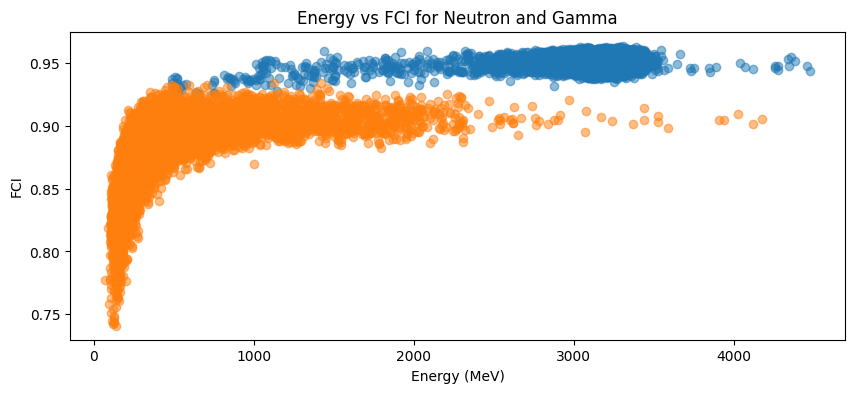

In [5]:
plt.figure(figsize=(10, 4))
plt.scatter(neutron['Energy'], neutron['FCI'], label='Neutron', alpha=0.5)
plt.scatter(gamma['Energy'], gamma['FCI'], label='Gamma', alpha=0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('FCI')
plt.title('Energy vs FCI for Neutron and Gamma')

Gamma dataset shape:  (10913, 3004)
Neutron dataset shape:  (27696, 3004)


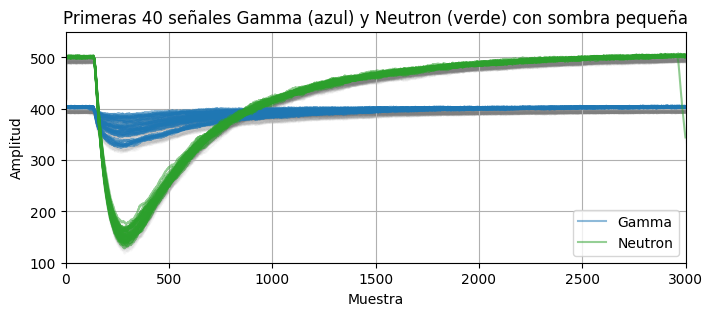

In [8]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", gamma.shape)
print("Neutron dataset shape: ", neutron.shape)
gamma.head()
neutron.head()

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(40):
    y = gamma.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(40):
    y = neutron.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 3000)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

# tomar solo 160 datos de los 3000

In [29]:
indices = np.linspace(100, 2500 - 1, 161, dtype=int)
newNeutron = neutron.iloc[:, indices].values
newGamma = gamma.iloc[:, indices].values

Gamma dataset shape:  (10913, 161)
Neutron dataset shape:  (27696, 161)


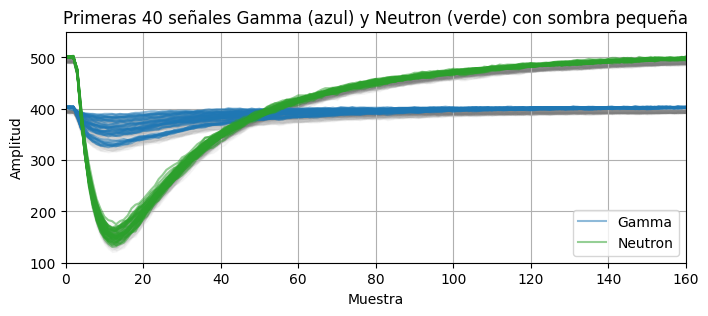

In [30]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", newGamma.shape)
print("Neutron dataset shape: ", newNeutron.shape)

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(40):
    y = newGamma[i, :]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(40):
    y = newNeutron[i, :]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 160)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

In [31]:
# Convertir a DataFrame
df_neutron = pd.DataFrame(newNeutron)
df_gamma = pd.DataFrame(newGamma)

# Agregar columna de clase
df_neutron["class"] = 1
df_gamma["class"] = 0

n_samples = 1000

# Seleccionar test
test_neutron = df_neutron.sample(n=n_samples, random_state=42)
test_gamma = df_gamma.sample(n=n_samples, random_state=42)

# Crear train eliminando esas filas
train_neutron = df_neutron.drop(test_neutron.index)
train_gamma = df_gamma.drop(test_gamma.index)

# Construir datasets finales
test_df = pd.concat([test_neutron, test_gamma], axis=0)
train_df = pd.concat([train_neutron, train_gamma], axis=0)

# Mezclar filas
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV
test_df.to_csv("dataset/test_dataset.csv", index=False)
train_df.to_csv("dataset/train_dataset.csv", index=False)